In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


In [16]:
print("Saravanan 24BAD105")
# Step 2: Upload ratings.csv and movies.csv

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)


Saravanan 24BAD105
Ratings Shape: (105339, 4)
Movies Shape: (10329, 3)


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
# Step 3: Data Preprocessing

ratings = ratings[['userId','movieId','rating']]

# Train-Test Split
train_data, test_data = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train Data Shape:", train_data.shape)
print("Test Data Shape :", test_data.shape)

Train Data Shape: (84271, 3)
Test Data Shape : (21068, 3)


In [6]:

# Step 4: Create User-Item Interaction Matrix

user_item_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)

# Fill missing values
matrix_filled = user_item_matrix.fillna(0)

User-Item Matrix Shape: (668, 9588)


In [7]:
# Step 5: Normalize Matrix

user_means = user_item_matrix.mean(axis=1)

normalized_matrix = user_item_matrix.sub(
    user_means,
    axis=0
).fillna(0)

normalized_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,-0.811321,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.784314,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:

# Step 6 & 7: Apply SVD and Reduce Dimensions

k_values = [5, 10, 20, 50]

rmse_list = []
mae_list = []

for k in k_values:

    print("\nProcessing k =", k)

    svd = TruncatedSVD(
        n_components=k,
        random_state=42
    )

    U = svd.fit_transform(normalized_matrix)

    Sigma = svd.singular_values_

    Vt = svd.components_

    # Step 8: Reconstruct Matrix
    reconstructed = np.dot(
        U,
        np.dot(np.diag(Sigma), Vt)
    )

    reconstructed = reconstructed + \
        user_means.values.reshape(-1, 1)

    reconstructed_df = pd.DataFrame(
        reconstructed,
        index=user_item_matrix.index,
        columns=user_item_matrix.columns
    )

    # Step 9: Predict Ratings
    preds = []
    actuals = []

    for row in test_data.itertuples():

        user = row.userId
        movie = row.movieId

        if user in reconstructed_df.index \
           and movie in reconstructed_df.columns:

            pred = reconstructed_df.loc[user, movie]

            preds.append(pred)

            actuals.append(row.rating)

    # Evaluation Metrics
    rmse = np.sqrt(
        mean_squared_error(actuals, preds)
    )

    mae = mean_absolute_error(
        actuals,
        preds
    )

    rmse_list.append(rmse)
    mae_list.append(mae)

    print("RMSE:", rmse)
    print("MAE :", mae)



Processing k = 5
RMSE: 7.334079243525354
MAE : 3.638830114273528

Processing k = 10
RMSE: 6.97374642568481
MAE : 3.6734524994306588

Processing k = 20
RMSE: 6.553128566237094
MAE : 3.657081858888294

Processing k = 50
RMSE: 5.693605642463903
MAE : 3.3677586125503143


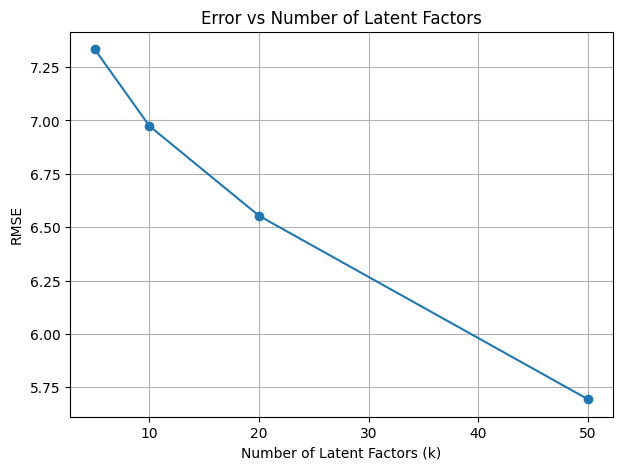

In [9]:

# Visualization: Error vs Number of Latent Factors

plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    rmse_list,
    marker='o'
)

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Number of Latent Factors")

plt.grid()

plt.show()

In [10]:
# Final Model using Best k

best_k = 50

svd_final = TruncatedSVD(
    n_components=best_k,
    random_state=42
)

U_final = svd_final.fit_transform(
    normalized_matrix
)

Sigma_final = svd_final.singular_values_

Vt_final = svd_final.components_

reconstructed_final = np.dot(
    U_final,
    np.dot(np.diag(Sigma_final), Vt_final)
)

reconstructed_final = reconstructed_final + \
    user_means.values.reshape(-1, 1)

reconstructed_df_final = pd.DataFrame(
    reconstructed_final,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

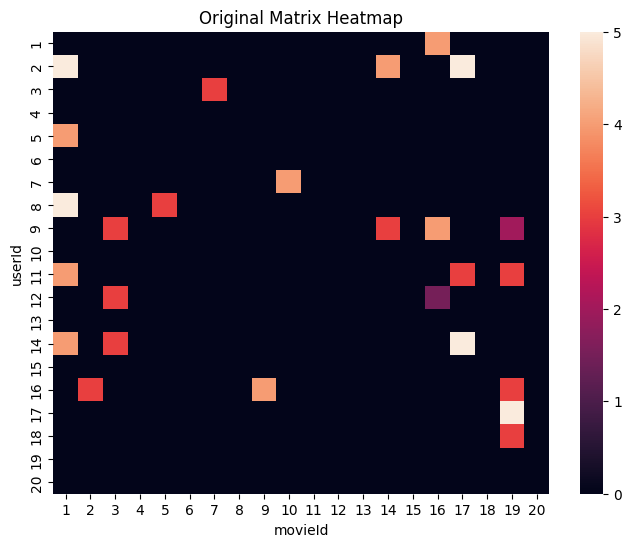

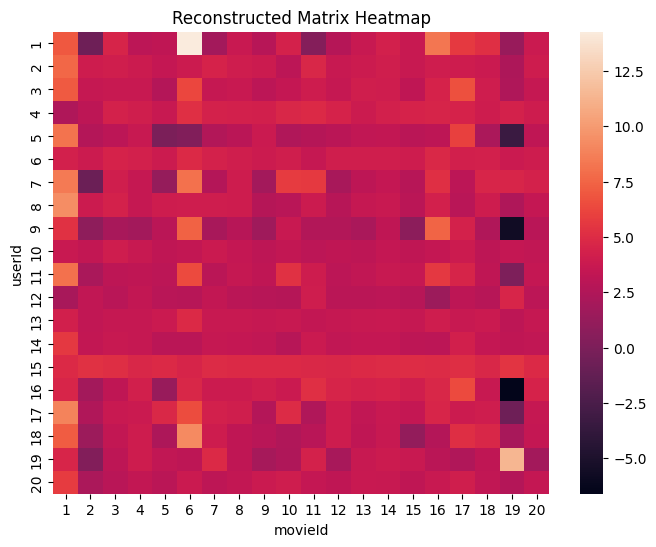

In [11]:

# Heatmap: Original vs Reconstructed

sample_original = matrix_filled.iloc[:20,:20]

sample_reconstructed = \
    reconstructed_df_final.iloc[:20,:20]

plt.figure(figsize=(8,6))

sns.heatmap(sample_original)

plt.title("Original Matrix Heatmap")

plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(sample_reconstructed)

plt.title("Reconstructed Matrix Heatmap")

plt.show()

In [12]:
# Step 10: Generate Top-N Recommendations

sample_user = reconstructed_df_final.index[0]

user_ratings = reconstructed_df_final.loc[
    sample_user
]

already_rated = user_item_matrix.loc[
    sample_user
].dropna().index

recommendations = user_ratings.drop(
    already_rated
)

top_n = recommendations.sort_values(
    ascending=False
).head(10)

top_movies = movies[
    movies['movieId'].isin(top_n.index)
]

print("\nTop 10 Recommended Movies for User:",
      sample_user)

print(top_movies[['movieId','title']])


Top 10 Recommended Movies for User: 1
      movieId                                              title
5           6                                        Heat (1995)
258       293  Léon: The Professional (a.k.a. The Professiona...
695       858                              Godfather, The (1972)
956      1193             One Flew Over the Cuckoo's Nest (1975)
959      1197                         Princess Bride, The (1987)
962      1200                                      Aliens (1986)
967      1206                         Clockwork Orange, A (1971)
975      1214                                       Alien (1979)
1050     1291          Indiana Jones and the Last Crusade (1989)
3322     4226                                     Memento (2000)


In [13]:
# Compare Predicted vs Actual Ratings

comparison_df = pd.DataFrame({
    "Actual": actuals[:20],
    "Predicted": preds[:20]
})

print("\nPredicted vs Actual Ratings:")

comparison_df


Predicted vs Actual Ratings:


,Actual,Predicted
0,3.0,3.811323
1,4.0,4.313054
2,4.0,9.726720
3,2.0,2.700446
4,2.0,-3.075258
5,3.0,-5.657693
6,5.0,7.518176
7,2.0,5.383591
8,2.5,-6.790118
9,3.0,5.727163


In [14]:
# Final Evaluation Results

results_df = pd.DataFrame({

    "Latent Factors (k)": k_values,

    "RMSE": rmse_list,

    "MAE": mae_list

})

results_df

,Latent Factors (k),RMSE,MAE
0,5,7.334079,3.638830
1,10,6.973746,3.673452
2,20,6.553129,3.657082
3,50,5.693606,3.367759


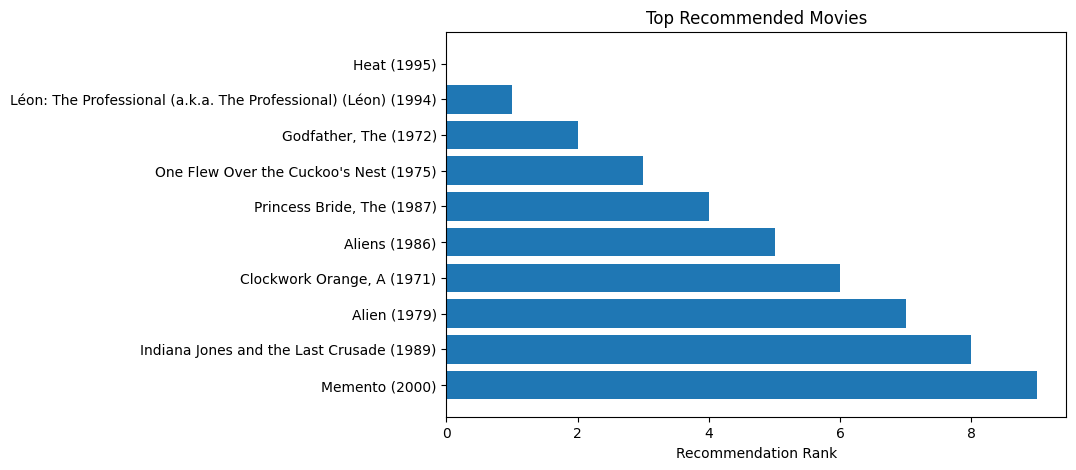

In [15]:

# Visualization: Top Recommended Movies

top_movies_titles = top_movies['title']

plt.figure(figsize=(8,5))

plt.barh(
    top_movies_titles,
    range(len(top_movies_titles))
)

plt.xlabel("Recommendation Rank")

plt.title("Top Recommended Movies")

plt.gca().invert_yaxis()

plt.show()